In [5]:
#Load an appropriate sample dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('titanic')

# Display first few rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

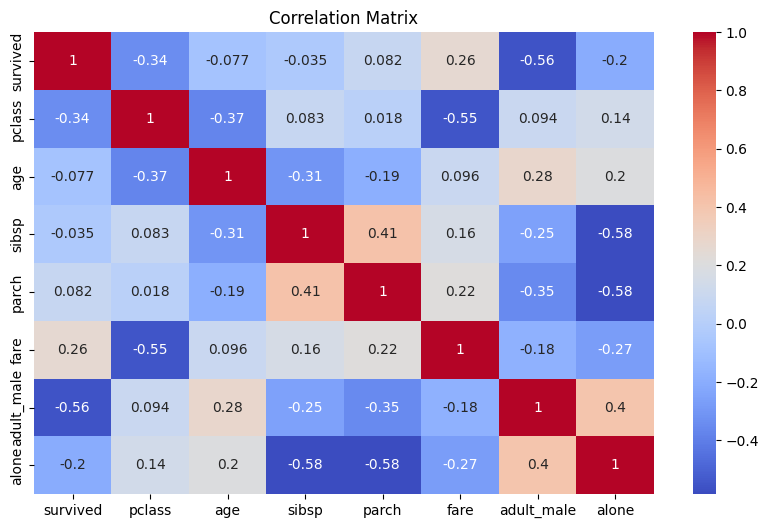

In [6]:
# Basic info
print(df.info())

# Summary statistics
print(df.describe())

# Check categorical columns
print(df.describe(include='object'))

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [7]:
#null values
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


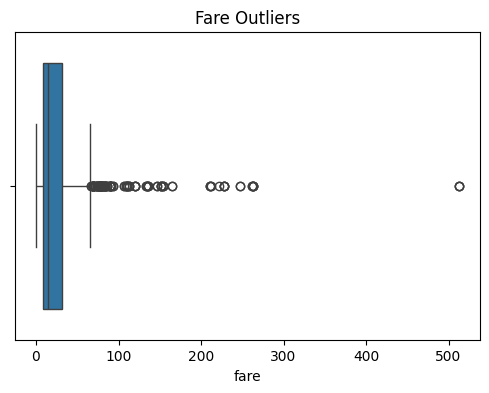

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare'])
plt.title("Fare Outliers")
plt.show()

In [9]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping (Winsorization)
df['fare'] = np.where(df['fare'] > upper_bound, upper_bound, df['fare'])
df['fare'] = np.where(df['fare'] < lower_bound, lower_bound, df['fare'])

In [10]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

print(df_encoded.head())

   survived  pclass   age  sibsp  parch     fare  class    who  adult_male  \
0         0       3  22.0      1      0   7.2500  Third    man        True   
1         1       1  38.0      1      0  65.6344  First  woman       False   
2         1       3  26.0      0      0   7.9250  Third  woman       False   
3         1       1  35.0      1      0  53.1000  First  woman       False   
4         0       3  35.0      0      0   8.0500  Third    man        True   

  deck  embark_town alive  alone  sex_male  embarked_Q  embarked_S  
0  NaN  Southampton    no  False      True       False        True  
1    C    Cherbourg   yes  False     False       False       False  
2  NaN  Southampton   yes   True     False       False        True  
3    C  Southampton   yes  False     False       False        True  
4  NaN  Southampton    no   True      True       False        True  


In [11]:
print("Before Scaling:")
print(df_encoded[['age', 'fare']].head())

Before Scaling:
    age     fare
0  22.0   7.2500
1  38.0  65.6344
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[['age', 'fare']] = scaler.fit_transform(df_encoded[['age', 'fare']])

In [13]:
print("After Scaling:")
print(df_encoded[['age', 'fare']].head())

After Scaling:
        age      fare
0 -0.530377 -0.820552
1  0.571831  2.031623
2 -0.254825 -0.787578
3  0.365167  1.419297
4  0.365167 -0.781471


In [14]:
print(df_encoded.head())

   survived  pclass       age  sibsp  parch      fare  class    who  \
0         0       3 -0.530377      1      0 -0.820552  Third    man   
1         1       1  0.571831      1      0  2.031623  First  woman   
2         1       3 -0.254825      0      0 -0.787578  Third  woman   
3         1       1  0.365167      1      0  1.419297  First  woman   
4         0       3  0.365167      0      0 -0.781471  Third    man   

   adult_male deck  embark_town alive  alone  sex_male  embarked_Q  embarked_S  
0        True  NaN  Southampton    no  False      True       False        True  
1       False    C    Cherbourg   yes  False     False       False       False  
2       False  NaN  Southampton   yes   True     False       False        True  
3       False    C  Southampton   yes  False     False       False        True  
4        True  NaN  Southampton    no   True      True       False        True  
